# Setup and Libraries

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, datasets
import imutils
from google.colab.patches import cv2_imshow



# Part 1: Advanced Preprocessing

## Task 1.1: Perspective Correction

In [18]:
def order_points(pts):
    # Order: top-left, top-right, bottom-right, bottom-left
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def four_point_transform(image, pts):
    rect = order_points(pts) [cite: 24, 25]
    (tl, tr, br, bl) = rect

    # Compute width and height of the new image
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points for a "birds-eye view"
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst) [cite: 34]
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight)) [cite: 35]
    return warped

## Task 1.2 & 1.3: Deskewing and Morphological Operations

In [19]:
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) [cite: 39, 41]
    gray = cv2.bitwise_not(gray) [cite: 42]
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1] [cite: 40, 48]

    coords = np.column_stack(np.where(thresh > 0)) [cite: 49, 54]
    angle = cv2.minAreaRect(coords)[-1] [cite: 50, 58]

    if angle < -45:
        angle = -(90 + angle) [cite: 47, 58]
    else:
        angle = -angle [cite: 45, 59]

    (h, w) = image.shape[:2] [cite: 57]
    center = (w // 2, h // 2) [cite: 46, 51]
    M = cv2.getRotationMatrix2D(center, angle, 1.0) [cite: 51]
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE) [cite: 51, 52]
    return rotated, angle

# Morphological Operations Example [cite: 60, 61]
def apply_morphology(gray_img):
    kernel = np.ones((3, 3), np.uint8) [cite: 61]
    erosion = cv2.erode(gray_img, kernel, iterations=1) [cite: 61]
    dilation = cv2.dilate(gray_img, kernel, iterations=1) [cite: 61]
    opening = cv2.morphologyEx(gray_img, cv2.MORPH_OPEN, kernel) [cite: 61]
    closing = cv2.morphologyEx(gray_img, cv2.MORPH_CLOSE, kernel) [cite: 61]
    return erosion, dilation, opening, closing

<>:15: SyntaxWarning: tuple indices must be integers or slices, not tuple; perhaps you missed a comma?
<>:15: SyntaxWarning: tuple indices must be integers or slices, not tuple; perhaps you missed a comma?
/tmp/ipykernel_11543/2209800684.py:15: SyntaxWarning: tuple indices must be integers or slices, not tuple; perhaps you missed a comma?
  center = (w // 2, h // 2) [cite: 46, 51]


# Part 2: CNN from Scratch

## Task 2.1 - 2.2: Data Prep

In [20]:
# Load MNIST
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and Normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## Task 2.3 - 2.4: Architecture and Training

In [21]:
model = keras.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Task 2.4: Train the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)
# accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.8998 - loss: 0.3260 - val_accuracy: 0.9795 - val_loss: 0.0603
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9699 - loss: 0.0989 - val_accuracy: 0.9865 - val_loss: 0.0456
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9779 - loss: 0.0753 - val_accuracy: 0.9872 - val_loss: 0.0414
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.9816 - loss: 0.0609 - val_accuracy: 0.9898 - val_loss: 0.0424
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9845 - loss: 0.0510 - val_accuracy: 0.9897 - val_loss: 0.0337
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9905 - val_loss: 0.0353
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9878 - loss: 0.0392 - val_accuracy: 0.9915 - val_loss: 0.0312
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9896 - loss: 0.0347 - 

## Task 2.4 Plot Training History

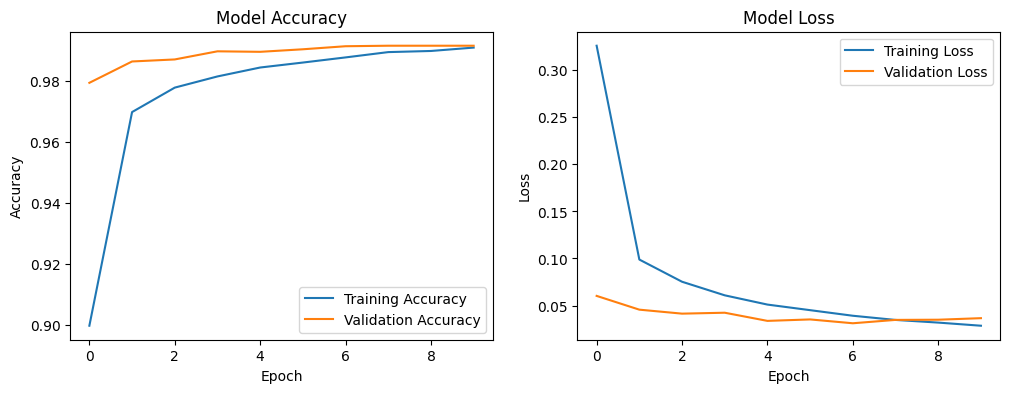

In [22]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


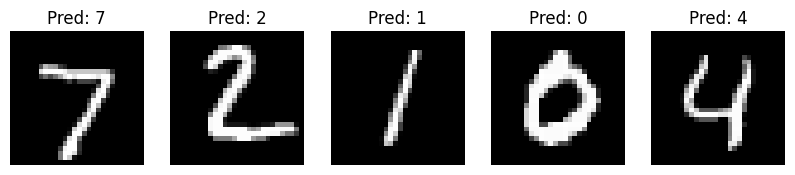

In [23]:
# predictions
predictions = model.predict(x_test[:5])

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}")
    plt.axis('off')
plt.show()

In [24]:
from google.colab import files
import cv2

uploaded = files.upload()

filename = list(uploaded.keys())[0]

import os
os.rename(filename, 'receipt.jpg')

print(f"Successfully uploaded and renamed to receipt.jpg")

Saving WhatsApp Image 2026-04-26 at 9.04.20 PM.jpeg to WhatsApp Image 2026-04-26 at 9.04.20 PM.jpeg
Successfully uploaded and renamed to receipt.jpg


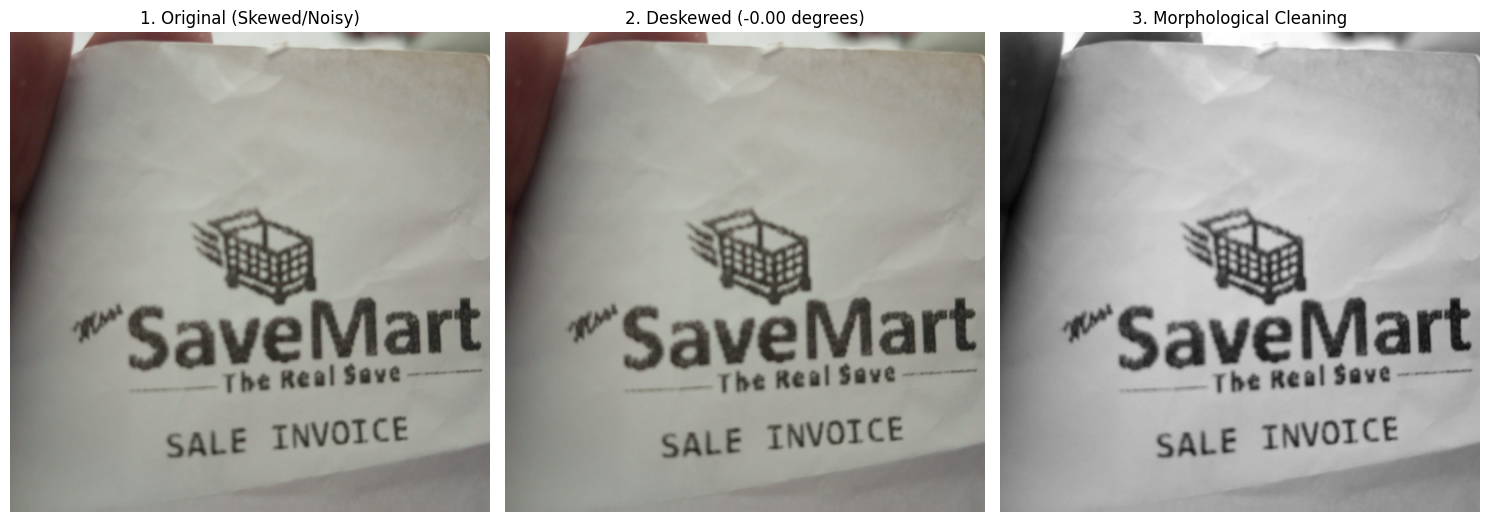

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Load the freshly uploaded image
img = cv2.imread('receipt.jpg')

# 2. Apply Automatic Deskewing (Task 1.2)
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    # Find coordinates of all non-zero pixels
    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust angle for rotation
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated, angle

rotated, angle = deskew(img)

# 3. Apply Morphological Operations (Task 1.3)
gray_rotated = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
kernel = np.ones((3, 3), np.uint8)
# Opening to remove background noise
cleaned = cv2.morphologyEx(gray_rotated, cv2.MORPH_OPEN, kernel)

# 4. Display Results for your Deliverables
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("1. Original (Skewed/Noisy)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title(f"2. Deskewed ({angle:.2f} degrees)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cleaned, cmap='gray')
plt.title("3. Morphological Cleaning")
plt.axis('off')

plt.tight_layout()
plt.show()